<a href="https://colab.research.google.com/github/DiegoAbarza77/Mineria_de_Datos/blob/main/Entrega_N3_Mineria_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrega de Mineria de Datos 1

***Integrantes:***

***Ignacio Rivera***

***Diego Abarza***

# Contexto
En este estudio veremos los patrones de uso de teléfonos inteligentes y su relación con el nivel de adicción. Utiliza un conjunto de datos que incluye variables demográficas como la edad y el género, junto con métricas de uso digital como horas diarias de pantalla, tiempo en redes sociales, tiempo de juego, horas de sueño, notificaciones y aperturas de aplicaciones.

Los objetivos clave del proyecto parecen ser:

***Exploración de Datos***: Entender la distribución de las variables y la presencia de valores nulos, así como las características generales de la población estudiada.

***Preparación de Datos***: Manejar valores faltantes (como la imputación por moda en addiction_level) y transformar variables categóricas a formatos numéricos (One-Hot Encoding y Ordinal Encoding) para su uso en modelos de Machine Learning.

***Análisis Descriptivo y Visualización***: Investigar la prevalencia de la adicción (se encontró un 70.77% de personas adictas en la muestra), la distribución de los niveles de adicción (con un 81.7% en niveles moderados a severos), la relación entre la edad y los niveles de adicción, y las correlaciones entre el tiempo de pantalla y otras variables de comportamiento digital.

En resumen, el proyecto busca identificar patrones y factores clave asociados con la adicción a los teléfonos inteligentes para comprender mejor este fenómeno.

# Fase 1 Importacion de librerias

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from IPython.display import clear_output as co
from matplotlib.ticker import MaxNLocator
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from google.colab import files



In [13]:
df = pd.read_csv("/content/Smartphone_Usage_And_Addiction.csv")

# Fase 2 Comprender los Datos

In [14]:
df.shape

(7500, 16)

In [15]:
df.head(100)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,TXN00096,U00096,31,Male,10.81,4.47,3.87,3.80,6.08,167,144,11.84,High,No,Moderate,1
96,TXN00097,U00097,29,Male,10.61,2.52,3.05,3.66,8.13,236,158,13.55,High,Yes,Severe,1
97,TXN00098,U00098,23,Male,5.46,4.69,3.69,2.43,5.32,56,159,7.60,Low,Yes,Moderate,1
98,TXN00099,U00099,34,Other,4.94,2.81,1.36,2.54,7.75,218,160,6.93,Low,Yes,NaN,0


In [16]:
df.columns

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')

In [17]:
for feature in df.columns:
  print('Total de valores nulos de', feature, '=', df[feature].isna().
  sum())

Total de valores nulos de transaction_id = 0
Total de valores nulos de user_id = 0
Total de valores nulos de age = 0
Total de valores nulos de gender = 0
Total de valores nulos de daily_screen_time_hours = 0
Total de valores nulos de social_media_hours = 0
Total de valores nulos de gaming_hours = 0
Total de valores nulos de work_study_hours = 0
Total de valores nulos de sleep_hours = 0
Total de valores nulos de notifications_per_day = 0
Total de valores nulos de app_opens_per_day = 0
Total de valores nulos de weekend_screen_time = 0
Total de valores nulos de stress_level = 0
Total de valores nulos de academic_work_impact = 0
Total de valores nulos de addiction_level = 819
Total de valores nulos de addicted_label = 0


In [18]:
print(df.dtypes)

transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object


# Realizaremos un mapeo de datos y una Clasificacion de Variables


'**transaction_id**': categorico nominal ya que es un identificador unico qu enoas ayuda a reconocer o identificar.

'**user_id**': Categórico Nominal, al igual que el anterior, funciona como una etiqueta única por usuario.

'**age**': Numérico Discreto. Generalmente se cuenta en años enteros (aunque en salud extrema podría ser continuo, aquí es discreto).

'**gender**': Categórico Nominal. Son Categorías sin un orden en especifico  (Masculino, Femenino, No binario, etc.).

'**daily_screen_time_hours**': Numérico Continuo. Es una medición de tiempo que puede incluir minutos y segundos (ej. 5.5 horas).

'***social_media_hours***': Numérico Continuo, es una medición de tiempo en este caso seria cuantas horas pasa en redes sociales(admite decimales)

'**gaming_hours**': Numérico Continuo, tambien es una medición de tiempo en este caso cuantas horas juega (admite decimales)

'**work_study_hours**': Numérico Continuo, es una medición de tiempo en este caso cuantas horas estudia la persona (admite decimales)

'**sleep_hours**': Numérico Continuo, es una medición de tiempo en este caso seria las horas que una persona puede dormir o duerme (admite decimales)

'**notifications_per_day**': Numérico Discreto, este surge de un conteo de eventos (no puedes recibir 10.5 notificaciones).

'**app_opens_per_day**': Numérico Discreto, conteo de acciones de apertura (números enteros).

'**weekend_screen_time**': Numérico Continuo, es una medición de tiempo total cuanto timepo en pantalla pasa en el fin de semana.

'**stress_level**': Categórico Ordinal, este generalmente se mide en escalas (Bajo, Medio, Alto) que tienen un orden lógico.

'**academic_work_impact**': Categórico Ordinal, este suele ser una escala de impacto o simplemente si estudia de una manera elevada o no, en este caso YES o NO.

'**addiction_level**': Categórico Ordinal, escala de intensidad que sigue una jerarquía de gravedad (Mild,	Moderate, Severe)**

'**addicted_label**': Categórico Nominal	Generalmente es una clasificación binaria (Sí / No).

# Describe
***En general, estas estadísticas nos dan una primera vista de la centralización, dispersión y forma de las distribuciones de cada variable numérica, lo cual es fundamental para entender el comportamiento de los datos antes de realizar análisis más profundos o construir modelos.***

In [19]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


# Ejemplo
***El rango de edad de los participantes va de 18 a 35 años, con un promedio de aproximadamente 26.57 años. La desviación estándar (5.19) sugiere una dispersión moderada alrededor de la media.***

# Types
***El siguiente codigo lo utilizaremos para mostrar los tipos de datos de cada columna en el DataFrame df. Esto es útil para entender cómo Pandas interpreta los datos en cada columna (por ejemplo, si son números enteros, números decimales, objetos, etc.), lo cual es crucial para operaciones de limpieza y análisis de datos.***

In [20]:
print(df.dtypes)

transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object


# Fase 3 Tratamiento de los datos

#Valores nulos
***hay que identificar y contar la cantidad de valores nulos o ausentes en cada columna de este dataframe, al fianl encontramos 819 valores nulos en addiction_level***


# Graficando valores nulos
***El siguiente código primero identifica y calcula el porcentaje de valores nulos en cada columna de nuestro DataFrame. Luego, muestra esta información en una tabla y la visualiza en un gráfico de barras para que puedas ver rápidamente qué columnas tienen datos faltantes y en qué proporción.
Mas que nada lo hacemos para ver de mejor manera
que se puede observar? : se observa que la columna addiction_label tiene 819 valores nulos representados en un 10.92%***

                 Valores faltantes  Porcentaje (%)
addiction_level                819           10.92


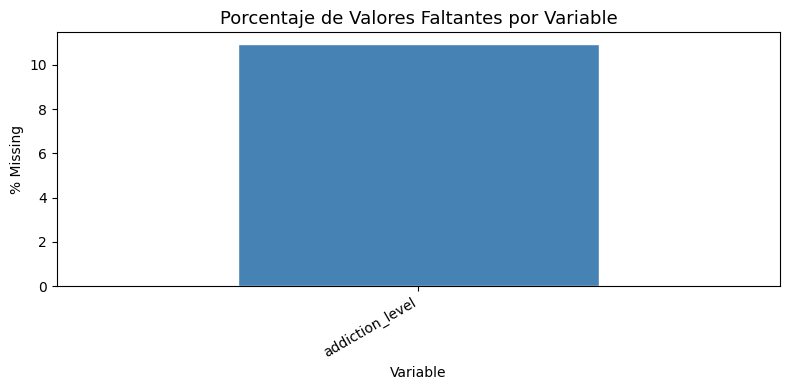

In [21]:
# Conteo y porcentaje de valores faltantes por columna
missing = pd.DataFrame({
    'Valores faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Valores faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)
print(missing)

# Visualización
if not missing.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    missing['Porcentaje (%)'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Porcentaje de Valores Faltantes por Variable', fontsize=13)
    ax.set_ylabel('% Missing')
    ax.set_xlabel('Variable')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# Limpieza de datos nulos
Aca realizamos una limpieza de datos , en donde imputamos los nulos con la MODA

***Para manejar los valores nulos, primero los identificamos y contamos en cada columna, visualizándolos con un gráfico que reveló que la columna addiction_level tenía el 10.92% de sus datos faltantes. Luego, para esta columna categórica ordinal, rellenamos esos 819 valores nulos con la moda (el valor más frecuente) para mantener la integridad de los datos y asegurar la consistencia en el análisis posterior.***

In [22]:
ctext = ['addiction_level']

for columna in ctext:
    mode = df[columna].mode()[0]
    df[columna] = df[columna].fillna(mode)

***Como se podra ver aca ya hacemos otra visualizacion de los nulos y podemos ver que ya no hay mas valores faltantes***

In [23]:
for feature in df.columns:
  print('Total de valores nulos de', feature, '=', df[feature].isna().
  sum())

Total de valores nulos de transaction_id = 0
Total de valores nulos de user_id = 0
Total de valores nulos de age = 0
Total de valores nulos de gender = 0
Total de valores nulos de daily_screen_time_hours = 0
Total de valores nulos de social_media_hours = 0
Total de valores nulos de gaming_hours = 0
Total de valores nulos de work_study_hours = 0
Total de valores nulos de sleep_hours = 0
Total de valores nulos de notifications_per_day = 0
Total de valores nulos de app_opens_per_day = 0
Total de valores nulos de weekend_screen_time = 0
Total de valores nulos de stress_level = 0
Total de valores nulos de academic_work_impact = 0
Total de valores nulos de addiction_level = 0
Total de valores nulos de addicted_label = 0


# Desarrollo y visualizacion de los datos

***Este código calcula el porcentaje de personas adictas en tu conjunto de datos filtrando los registros donde addicted_label es 1, dividiendo este conteo por el total de registros, y multiplicando por 100 para obtener el porcentaje final, el cual luego se imprime formateado por ejemplo podemos ver que el porcentaje de personas adictas es mayor (70%)***

In [24]:
porcentaje_adictos = (df[df['addicted_label'] == 1].shape[0] / df.shape[0]) * 100
print(f"El porcentaje de personas adictas es: {porcentaje_adictos:.2f}%")

El porcentaje de personas adictas es: 70.77%


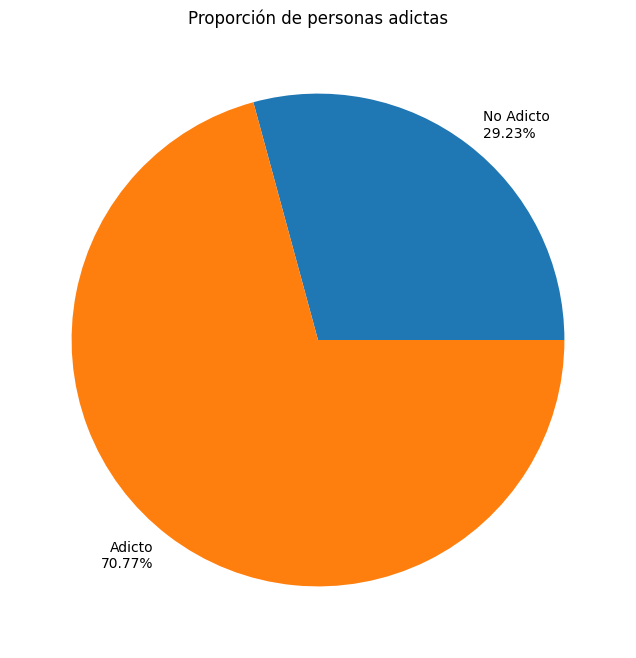

In [25]:
#conteo de adictos
conteo_adictos = df.groupby('addicted_label').size()

# % no adictos
porc_no_adictos = 100 - porcentaje_adictos

labels = []
labels.append(f'No Adicto\n{porc_no_adictos:.2f}%')
labels.append(f'Adicto\n{porcentaje_adictos:.2f}%')

plt.figure(figsize=(8, 8))
plt.pie(conteo_adictos, labels=labels, autopct='')
plt.title('Proporción de personas adictas')
plt.show()

>Agrupando la totalidad de nuestros datos según la etiqueta principal (addicted_label) para contar cuántas personas caen en la categoría de "Adicto" y cuántas en "No Adicto". Luego, calculamos los porcentajes exactos de cada grupo y los representamos en un gráfico de torta general.

>Para establecer la "línea base" o el panorama general de nuestro problema de estudio. Este gráfico nos revela un hallazgo crítico sobre nuestro dataset: existe un fuerte desbalance. Aproximadamente el 71% de nuestra muestra total clasifica como adicta a las pantallas, frente a solo un 29% que no lo es. Esto nos indica de entrada que, dentro de la población estudiada, el comportamiento adictivo es la norma y no la excepción

In [26]:
crosstab_result = pd.crosstab(df['addiction_level'], df['addicted_label'])
display(crosstab_result)

addicted_label,0,1
addiction_level,,
Mild,1373,0
Moderate,819,2874
Severe,0,2434


ACA VEMOS LA DISTRIBUCION QUE EXISTEN SEGUN EL NIVEL DE ADICCION EN DONDE VEMOS QUE MILD (LEVE) NO EXISTE NINGUNO Y EN SEVERE TODOS SON CONSIDERADOS ADICTOS

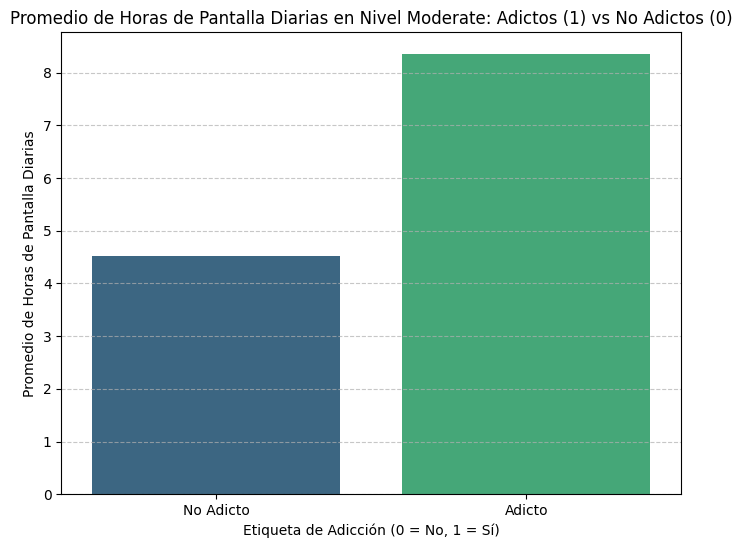

In [27]:

moderate_group = df[df['addiction_level'] == 'Moderate']


average_daily_screen_time = moderate_group.groupby('addicted_label')['daily_screen_time_hours'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='addicted_label', y='daily_screen_time_hours', data=average_daily_screen_time, palette='viridis')

plt.title('Promedio de Horas de Pantalla Diarias en Nivel Moderate: Adictos (1) vs No Adictos (0)')
plt.xlabel('Etiqueta de Adicción (0 = No, 1 = Sí)')
plt.ylabel('Promedio de Horas de Pantalla Diarias')
plt.xticks([0, 1], ['No Adicto', 'Adicto'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
co(wait=True)
plt.show()

ACA REALIZAMOS UN FILTRO DE NIVEL DE ADICCION EN DONDE EVALUAMOS LOS MODERADOS EN DONDE CALCULAMOS
# El promedio de horas de uso de pantalla diario (daily_screen_time_hours), segmentado por cada categoría de adicción (addicted_label), exclusivamente dentro del subgrupo "moderado" (moderate_group).

PARA VER EN UN GRAFICO LA CANTIDAD Y DIFERENCIAS QUE EXISTEN EN LA CATEGORIA MODERADOS ENTRE ADICTOS Y NO ADICTOS BASANDONOS EN LA CANTIDAD DE HORAS QUE ESTOS ESTAN FRENTE A PANTALLA QUE ESTA VARIABLE ES LA MAS IMPORTANTE PARA PODER CLASIFICAR SI ES ADICTO O NO

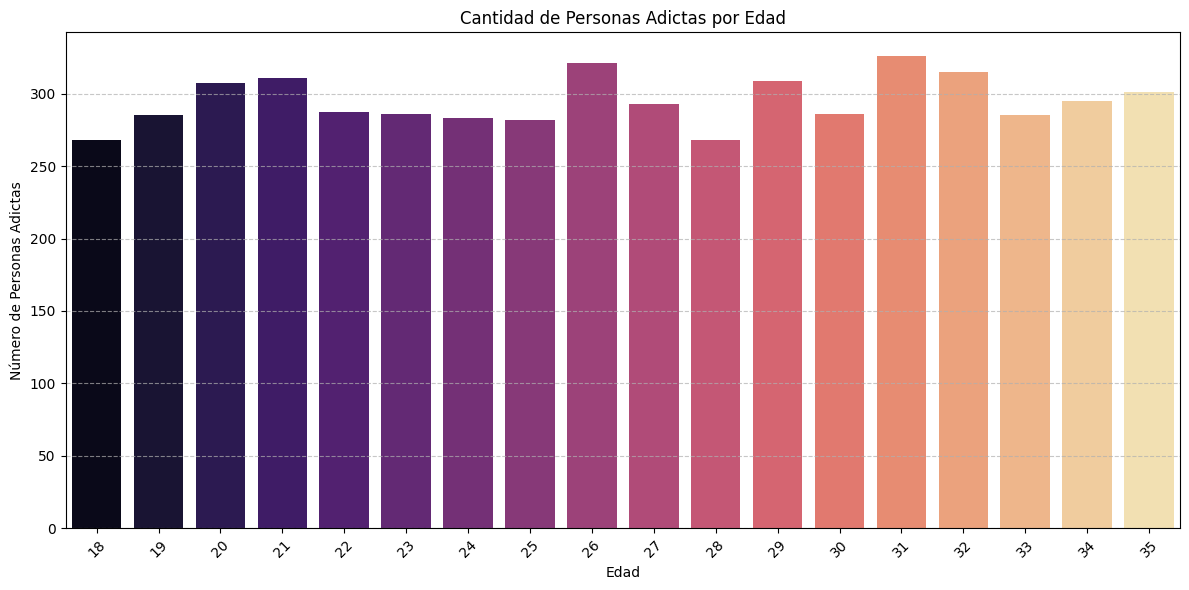

In [28]:

# Filtrar el DataFrame para obtener solo a las personas adictas
addicted_people = df[df['addicted_label'] == 1]

# Contar la cantidad de personas adictas por edad
addiction_by_age = addicted_people['age'].value_counts().sort_index().reset_index()
addiction_by_age.columns = ['age', 'count_of_addicted']


plt.figure(figsize=(12, 6))
sns.barplot(x='age', y='count_of_addicted', data=addiction_by_age, palette='magma')

plt.title('Cantidad de Personas Adictas por Edad')
plt.xlabel('Edad')
plt.ylabel('Número de Personas Adictas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
co(wait=True)
plt.show()

> filtramos el dataset para aislar exclusivamente a los usuarios clasificados como adictos (addicted_label == 1). Luego, contamos la cantidad exacta de estas personas para cada edad y generamos un gráfico de barras para visualizar estos conteos cronológicamente.

> Nos permite descubrir si existe una tendencia demográfica vinculada a la adicción. Al observar el gráfico, podemos analizar fácilmente si el comportamiento adictivo se concentra en un rango de edad específico (por ejemplo, usuarios más jóvenes) o si, por el contrario, se distribuye de manera relativamente uniforme a lo largo de todas las edades evaluadas (entre los 18 y 35 años).

> Utilizamos un gráfico de barras (sns.barplot) porque es la herramienta visual más efectiva para comparar frecuencias absolutas a través de categorías discretas o secuenciales


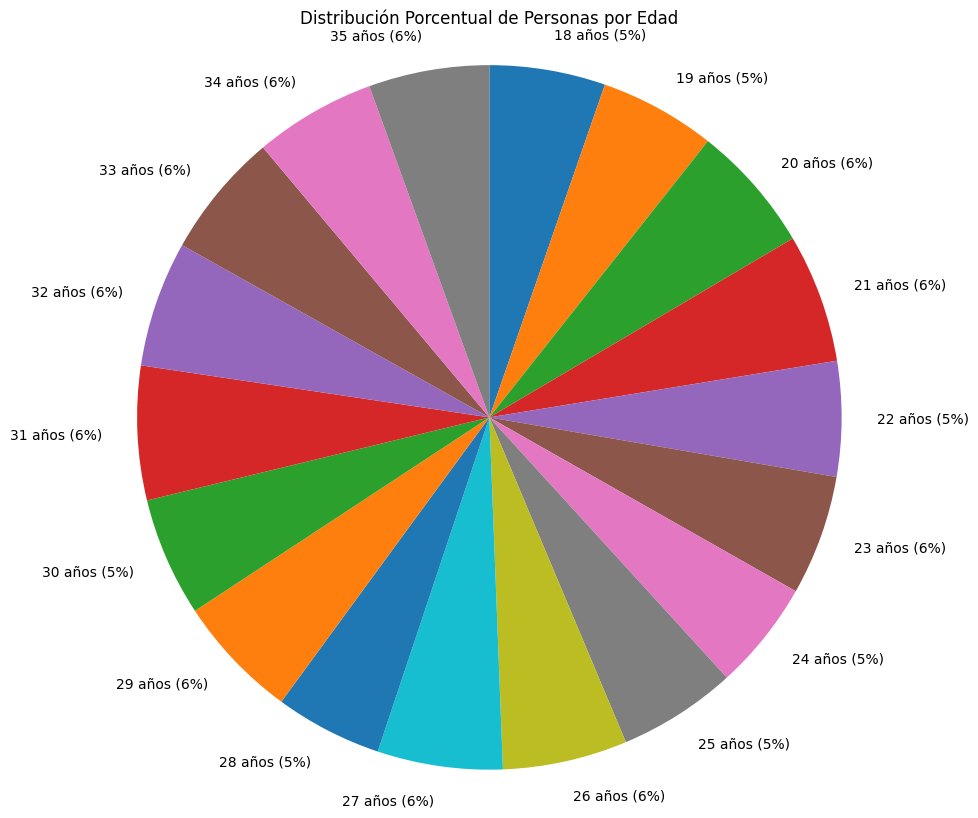

In [29]:

# Calcular el conteo de cada edad
age_counts = df['age'].value_counts().sort_index()

# Calcular los porcentajes
age_percentages = age_counts / age_counts.sum() * 100

# Crear las etiquetas para el gráfico de torta incluyendo la edad (como entero) y el porcentaje (sin decimales)
labels = [f'{int(age)} años ({percent:.0f}%)' for age, percent in age_percentages.items()]

plt.figure(figsize=(10, 10))
plt.pie(age_counts, labels=labels, autopct='', startangle=90, counterclock=False)
plt.title('Distribución Porcentual de Personas por Edad')
plt.axis('equal')
plt.show()

>Calculando la cantidad total de personas para cada edad en el dataset completo, transformando esos valores matemáticos en porcentajes, y visualizándolos mediante un gráfico de torta (pie chart)

> con esto podemosentender la composición demográfica de nuestra muestra en términos de proporciones relativas. En este caso específico, el resultado nos revela un hallazgo clave sobre la calidad de la muestra: nuestro dataset está perfectamente balanceado. Como se puede observar, cada edad (desde los 18 hasta los 35 años) representa casi la misma proporción exacta del total (entre un 5% y un 6%). Esto nos garantiza que los datos no están sesgados hacia un grupo de edad en particular

>Elegimos este tipo de gráfico porque su función estadística principal es mostrar "partes de un todo"

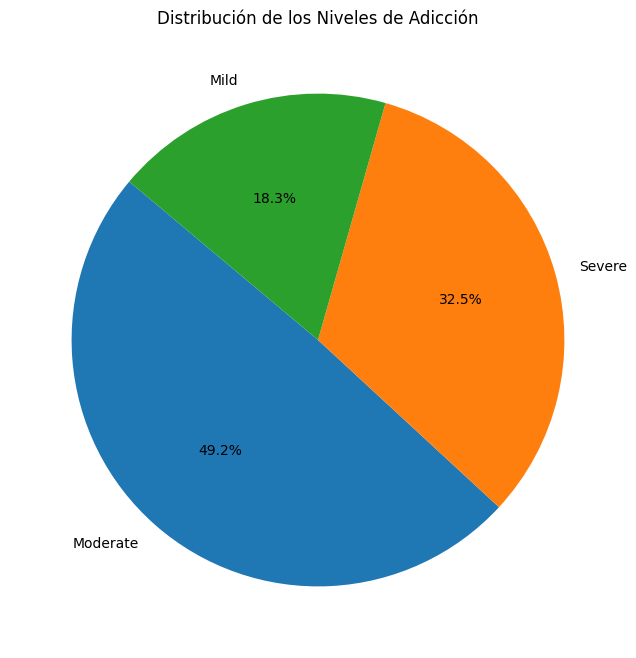

In [30]:
addiction_counts = df['addiction_level'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(addiction_counts, labels=addiction_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribución de los Niveles de Adicción')
plt.ylabel('') # Elimina el "Cantidad de Usuarios" redundante para el gráfico de torta
plt.show()

El gráfico revela una tendencia preocupante hacia niveles de adicción elevados, donde la categoría "Moderate" domina el conjunto de datos con un 49.2%, seguida por un significativo 32.5% en el nivel "Severe".

Al sumar ambos segmentos, se concluye que el 81.7% de los individuos analizados presentan una adicción de moderada a grave, mientras que solo una minoría del 18.3% se sitúa en el nivel "Mild".

Esta distribución sugiere que la gran mayoría de la población de la muestra requiere atención o intervención, destacando que el volumen de casos críticos y moderados supera por mucho a los casos leves, lo que podría indicar una muestra sesgada hacia poblaciones ya vulnerables o una problemática profundamente arraigada.

Este conjunto de histogramas revela que casi todas las variables numéricas (como la edad, las horas de redes sociales, el tiempo de estudio y las notificaciones) presentan una **distribución uniforme**, lo que significa que los datos están repartidos de manera prácticamente equitativa en todos los rangos y no hay una tendencia o "pico" natural en el comportamiento de los usuarios. La única excepción notable es el gráfico de **"weekend_screen_time"**, que muestra una distribución más cercana a una campana, con una concentración mayor de personas pasando entre 6 y 12 horas frente a la pantalla los fines de semana, bueno, finalmente, el histograma de **"addicted_label"** confirma visualmente lo que en el grafico que se vio antes, el grafico de tortas donde se ve que existe una gran mayoría de la muestra se agrupa en el valor más alto (cercano a 1.0), indicando que el dataset está compuesto por mas individuos con altos niveles de adicción.

# Histograma

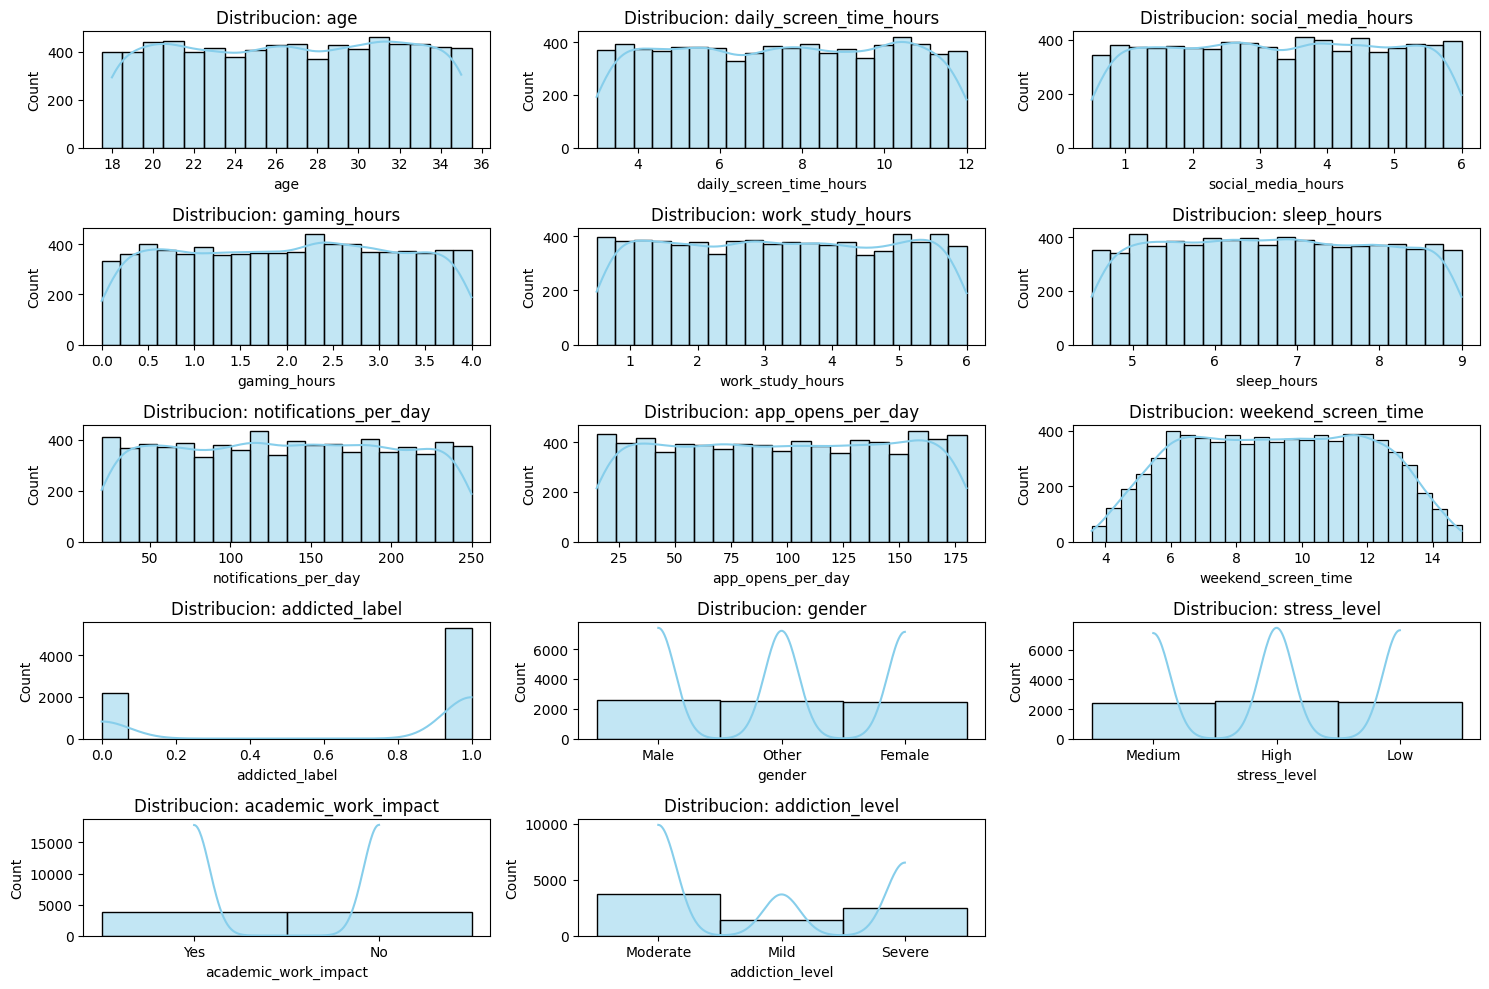

In [31]:
cols_numericas = [
    "age", "daily_screen_time_hours", "social_media_hours", "gaming_hours",
    "work_study_hours", "sleep_hours", "notifications_per_day",
    "app_opens_per_day", "weekend_screen_time", "addicted_label","gender", "stress_level", "academic_work_impact", "addiction_level"
]

# Configuracion de graficos
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_numericas, 1):
    # Capturamos el "eje" actual (subplot) en la variable 'ax'
    ax = plt.subplot(5, 3, i) # Changed from 4, 3 to 5, 3 to accommodate all 14 plots

    if col == 'age':
        sns.histplot(df[col], kde=True, color='skyblue', discrete=True)
        # Forzamos a que las etiquetas del eje X sean solo números enteros
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    else:
        sns.histplot(df[col], kde=True, color='skyblue')

    plt.title(f'Distribucion: {col}')

plt.tight_layout()
plt.show()

### Tratamiento de Outliers mediante el Método IQR

Vamos a filtrar los outliers de las columnas numéricas continuas principales para asegurar que los análisis posteriores no estén sesgados por valores extremos.

In [32]:
cols_continuas = [
    'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
    'work_study_hours', 'sleep_hours', 'weekend_screen_time'
]

def limpiar_outliers_iqr(df_input, columnas):
    df_limpio = df_input.copy()
    for col in columnas:
        Q1 = df_limpio[col].quantile(0.25)
        Q3 = df_limpio[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Filtrar el DataFrame
        antes = df_limpio.shape[0]
        df_limpio = df_limpio[(df_limpio[col] >= limite_inferior) & (df_limpio[col] <= limite_superior)]
        despues = df_limpio.shape[0]
        print(f'Columna {col}: Eliminados {antes - despues} outliers')

    return df_limpio

# Aplicar la limpieza
df_sin_outliers = limpiar_outliers_iqr(df, cols_continuas)

print(f'\nDimensiones originales: {df.shape}')
print(f'Dimensiones finales tras limpieza: {df_sin_outliers.shape}')
display(df_sin_outliers.describe())

Columna daily_screen_time_hours: Eliminados 0 outliers
Columna social_media_hours: Eliminados 0 outliers
Columna gaming_hours: Eliminados 0 outliers
Columna work_study_hours: Eliminados 0 outliers
Columna sleep_hours: Eliminados 0 outliers
Columna weekend_screen_time: Eliminados 0 outliers

Dimensiones originales: (7500, 16)
Dimensiones finales tras limpieza: (7500, 16)


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


>Estamos aplicando una función (limpiar_outliers_iqr) que automatiza la detección y eliminación de valores atípicos en nuestras variables numéricas continuas principales

>Nos permite "sanear" el dataset, garantizando que nuestros análisis estadísticos y modelos posteriores no se vean distorsionados o sesgados por registros extremos

>Elegimos este método porque es una medida estadística robusta. A diferencia de otros enfoques (como el Z-score basado en la media y desviación estándar), el IQR utiliza la mediana y los cuartiles (Q1 y Q3), lo que significa que el propio cálculo de los límites no se ve afectado por los valores extremos que precisamente queremos eliminar

In [33]:
df_sin_outliers.head(100)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,Moderate,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,Moderate,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,TXN00096,U00096,31,Male,10.81,4.47,3.87,3.80,6.08,167,144,11.84,High,No,Moderate,1
96,TXN00097,U00097,29,Male,10.61,2.52,3.05,3.66,8.13,236,158,13.55,High,Yes,Severe,1
97,TXN00098,U00098,23,Male,5.46,4.69,3.69,2.43,5.32,56,159,7.60,Low,Yes,Moderate,1
98,TXN00099,U00099,34,Other,4.94,2.81,1.36,2.54,7.75,218,160,6.93,Low,Yes,Moderate,0


### Codificación de Variables Categóricas

Utilizaremos `OneHotEncoder` para las variables nominales, asegurando que el modelo pueda procesar la información correctamente.

In [34]:
# definiimos las columnas que vamos a modificar
nominal_cols = ['gender', 'academic_work_impact', 'stress_level', 'addiction_level']

# aplicamos el onehotencoder luego de instanciar
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_data = encoder.fit_transform(df_sin_outliers[nominal_cols])

# nuevo dataframe
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(nominal_cols), index=df_sin_outliers.index)

# Concatenamos con el DataFrame original y eliminamos las columnas viejas
df_final = pd.concat([df_sin_outliers.drop(columns=nominal_cols), encoded_df], axis=1)

print("Nuevas columnas generadas por OneHotEncoder:")
display(encoded_df.head())

print("\nEstructura del DataFrame final:")
display(df_final.head())

Nuevas columnas generadas por OneHotEncoder:


,gender_Male,gender_Other,academic_work_impact_Yes,stress_level_Low,stress_level_Medium,addiction_level_Moderate,addiction_level_Severe
0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
1,0.0,1.0,1.0,0.0,1.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,1.0



Estructura del DataFrame final:


,transaction_id,user_id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label,gender_Male,gender_Other,academic_work_impact_Yes,stress_level_Low,stress_level_Medium,addiction_level_Moderate,addiction_level_Severe
0,TXN00001,U00001,21,3.23,2.01,0.89,4.55,7.55,248,154,3.95,0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
1,TXN00002,U00002,24,5.09,3.81,2.24,4.44,7.66,127,71,6.71,0,0.0,1.0,1.0,0.0,1.0,1.0,0.0
2,TXN00003,U00003,31,6.06,1.36,3.83,2.35,4.92,44,106,8.68,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,TXN00004,U00004,32,7.83,5.85,1.51,3.54,8.23,178,107,9.77,1,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,TXN00005,U00005,25,9.96,5.92,3.42,5.27,6.21,136,177,12.55,1,1.0,0.0,0.0,1.0,0.0,0.0,1.0


## one hot enconder

> Estamos aplicando un OneHotEncoder para transformar nuestras variables categóricas (columnas que contienen texto, como el género) en múltiples columnas nuevas compuestas únicamente por ceros y unos (formato binario).

>Es un paso obligatorio de preparación porque los algoritmos de Machine Learning son puramente matemáticos y no saben interpretar palabras. Con esta transformación, traducimos la información de texto a un lenguaje numérico limpio que el modelo sí puede procesar para encontrar patrones para evitar sesgos matematicos y optimizar el modelo.

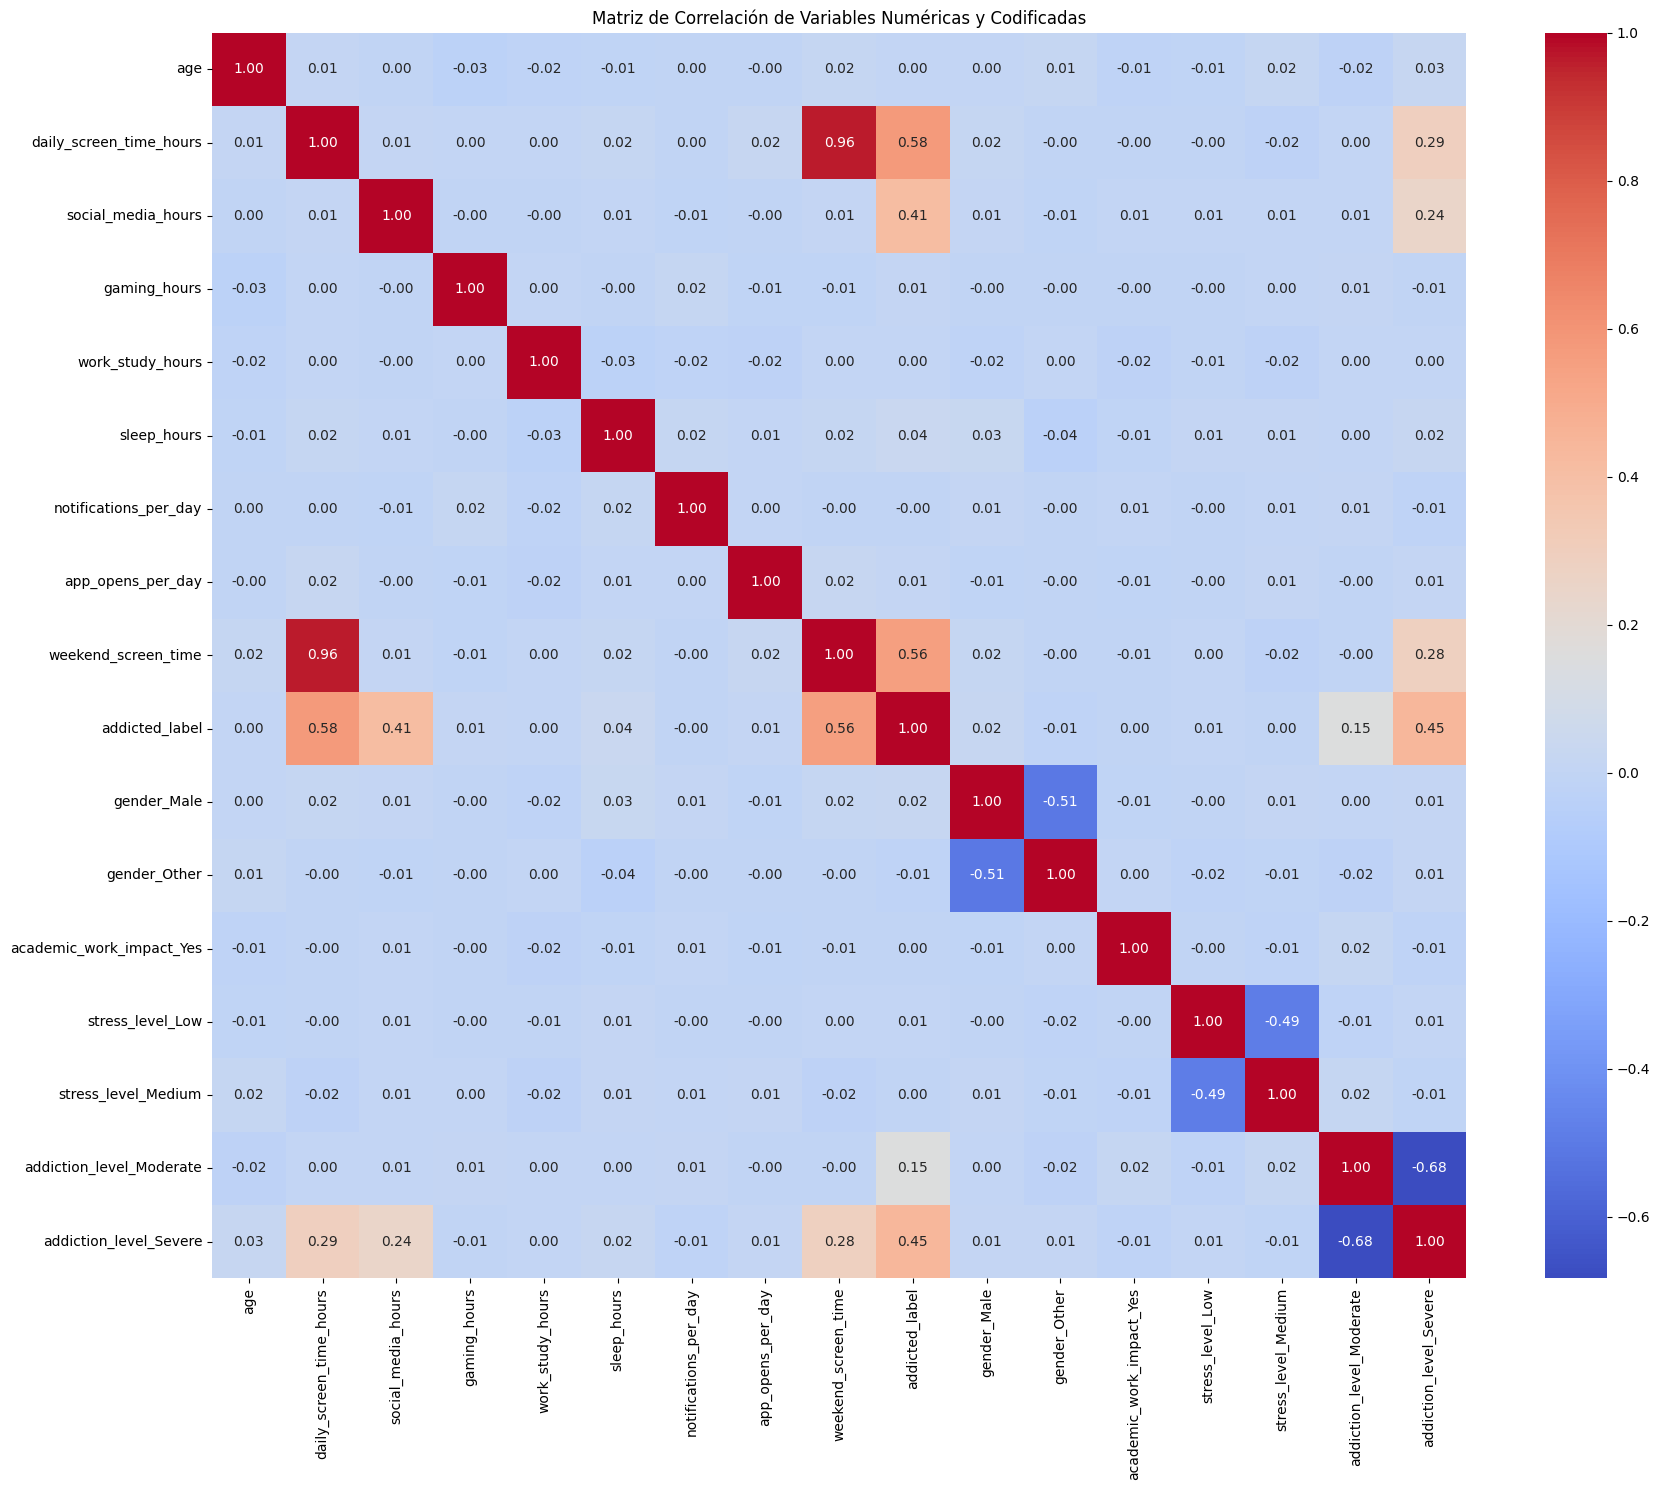

In [35]:
# Seleccionamos todas las columnas numéricas (incluyendo las creadas por OneHotEncoder)
numeric_cols_final = df_final.select_dtypes(include=np.number).columns

plt.figure(figsize=(18, 15)) # Aumentamos el tamaño para acomodar más columnas
sns.heatmap(df_final[numeric_cols_final].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Variables Numéricas y Codificadas')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Esta matriz de correlación (heatmap) analiza la relación entre diversas variables de comportamiento digital, y la conclusión principal es que el tiempo frente a la pantalla es el predictor más fuerte de la adicción. Se observa una correlación casi perfecta (0.96) entre daily_screen_time_hours y weekend_screen_time, lo que indica que los hábitos de uso son consistentes durante toda la semana. Respecto a la variable addicted_label, esta presenta una correlación positiva moderada-alta con el tiempo diario en pantalla (0.58) y el tiempo de fin de semana (0.56), seguida por el uso de redes sociales (0.41), sugiriendo que a mayor tiempo de exposición, mayor es el nivel de adicción reportado. Por el contrario, variables como la edad, las horas de sueño, el trabajo/estudio o la cantidad de notificaciones muestran correlaciones cercanas a cero, lo que implica que, en este conjunto de datos, estos factores no influyen directamente en la probabilidad de adicción de manera lineal.

### Análisis de Relevancia: Género vs Adicción
Visualizamos la proporción de personas adictas segmentadas por género para determinar si existe una diferencia significativa entre los grupos.
> aca vemos la cantidad en porcentaje de adictos que existe por cada genero

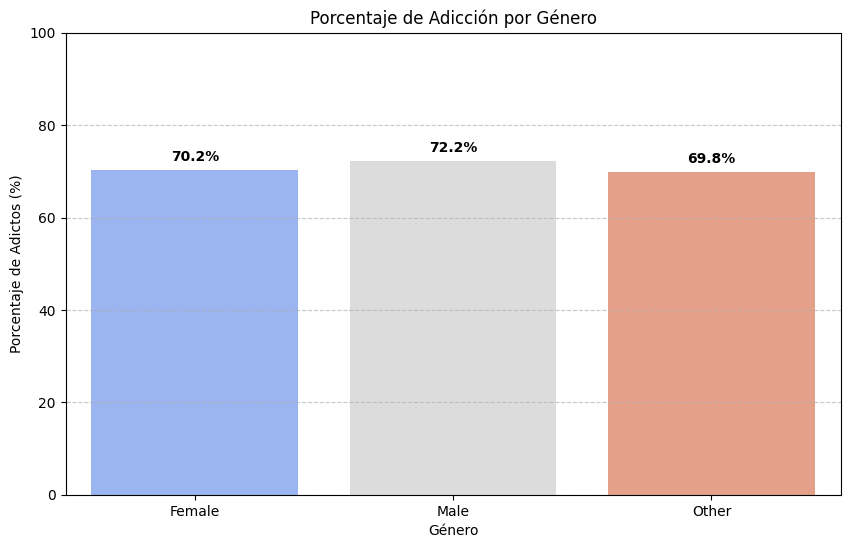

In [36]:
plt.figure(figsize=(10, 6))
# Calculamos el porcentaje de adicción por género
gender_addiction_pct = df.groupby('gender')['addicted_label'].mean() * 100

sns.barplot(x=gender_addiction_pct.index, y=gender_addiction_pct.values, palette='coolwarm')

plt.title('Porcentaje de Adicción por Género')
plt.xlabel('Género')
plt.ylabel('Porcentaje de Adictos (%)')
plt.ylim(0, 100)

for i, val in enumerate(gender_addiction_pct.values):
    plt.text(i, val + 2, f'{val:.1f}%', ha='center', fontweight='bold')

co(wait=True)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

>Estamos agrupando el conjunto de datos según el género de los usuarios (gender) para calcular qué porcentaje exacto de personas dentro de cada grupo está clasificado como adicto (addicted_label). Luego, visualizamos estos porcentajes en un gráfico de barras

>Para identificar si existe una brecha o sesgo de género en el comportamiento adictivo. Los resultados de este gráfico son muy reveladores: nos muestran que la tasa de adicción es alta y sumamente pareja en todas las categorías . Esto nos permite concluir que, dentro de esta muestra, el género no es un factor determinante ni diferenciador para la adicción a las pantallas.

>Usamos un gráfico de barras clásico, pero le agregamos el límite en el eje Y (plt.ylim(0, 100)) para que visualmente represente un "todo" porcentual real, y no exagere las diferencias.

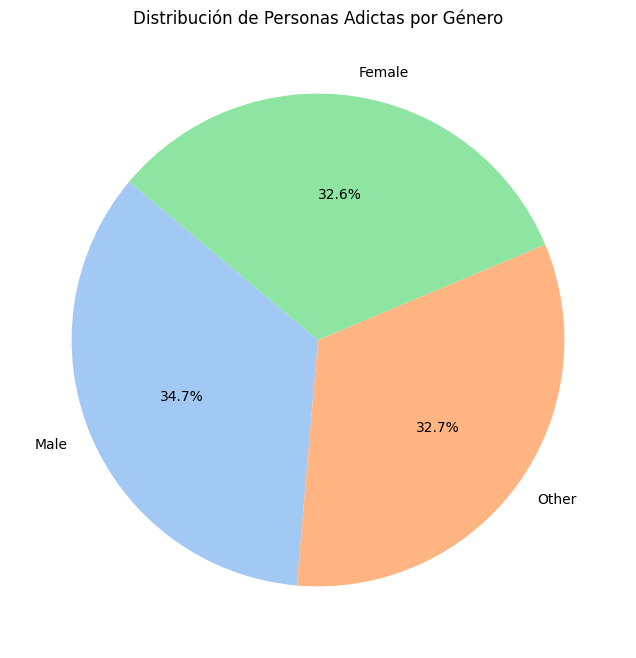

In [37]:
plt.figure(figsize=(8, 8))

# Filtramos solo a los adictos
addicted_only = df[df['addicted_label'] == 1]
gender_counts = addicted_only['gender'].value_counts()

# Crear el gráfico de torta
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))

plt.title('Distribución de Personas Adictas por Género')
plt.show()

A diferencia del gráfico anterior, aquí primero filtramos la base de datos para quedarnos únicamente con las personas que ya están clasificadas como adictas (addicted_label == 1). Luego, contamos cuántos de esos adictos pertenecen a cada categoría de género y lo representamos visualmente.

>nos sirve Para visualizar cómo está compuesto internamente el grupo de personas con adicción. Los resultados nos muestran que el total de usuarios adictos se divide en tres partes casi idénticas

>basandose en el analisis anterior no solo la tasa de adicción es igual en todos los géneros, sino que el grupo total de adictos está perfectamente balanceado.

#CONCLUSION


>A modo de cierre, el trabajo realizado sobre este conjunto de datos nos deja un panorama claro y fundamentado sobre los patrones de uso de smartphones y la adicción digital.

>Uno de los hallazgos más interesantes es que la adicción no discrimina por género ni por edad (dentro del rango de 18 a 35 años). Observamos que las tasas de adicción son casi idénticas entre hombres, mujeres y otros géneros, y se distribuyen de forma equitativa en todas las edades analizadas. Esto sugiere que el riesgo de adicción digital es un fenómeno transversal a la identidad del usuario.

>Notamos que variables como las notificaciones o el nivel de estrés no tienen una relación tan directa con la etiqueta de adicción como lo tiene el tiempo total de pantalla. Esto nos permite concluir que el volumen de uso es el síntoma más claro y el predictor definitivo, por encima de las interacciones pasivas (recibir alertas).

>En síntesis, este análisis comprueba que el tiempo de pantalla es la métrica definitiva para evaluar la salud digital. Los hábitos de estos usuarios están sumamente arraigados, al punto de que no hay mayor diferencia entre lo que hacen un martes o un domingo (lo que se refleja en esa altísima correlación de 0.96 entre días de semana y fines de semana). Todo este proceso de limpieza y exploración nos deja un terreno sólido para, en una siguiente etapa, construir modelos predictivos que pongan el foco exactamente ahí: en los tiempos de uso prolongado como la señal de alerta definitiva.

# PARTE 2, MODELOS DE PREDICCION O CLASIFICACION

# Paso 1: Separar las características (X) y el objetivo (y)

Antes de pasar los datos a los modelos, debemos quitar los identificadores (transaction_id y user_id) y separar la columna que queremos predecir (addicted_label) y tambien creamos el nuevo DATA FRAME


In [38]:
# 1. Creamos el nuevo DataFrame filtrando las columnas innecesarias
# Eliminamos los IDs y las columnas que son directamente el origen de la etiqueta objetivo
columnas_a_eliminar = ['transaction_id', 'user_id', 'addiction_level_Moderate', 'addiction_level_Severe']
df_para_modelos = df_final.drop(columns=columnas_a_eliminar)

# 2. Separamos las características (X) y la variable objetivo (y)
X_nuevo = df_para_modelos.drop(columns=['addicted_label'])
y_nuevo = df_para_modelos['addicted_label']

# Verificamos las columnas finales
print("Columnas que usará el modelo para aprender (sin leakage):")
print(X_nuevo.columns.tolist())

Columnas que usará el modelo para aprender (sin leakage):
['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender_Male', 'gender_Other', 'academic_work_impact_Yes', 'stress_level_Low', 'stress_level_Medium']


# Paso 2: Dividir los datos del nuevo DataFrame
Dividimos este nuevo conjunto en datos de entrenamiento (80%) y datos de prueba (20%).

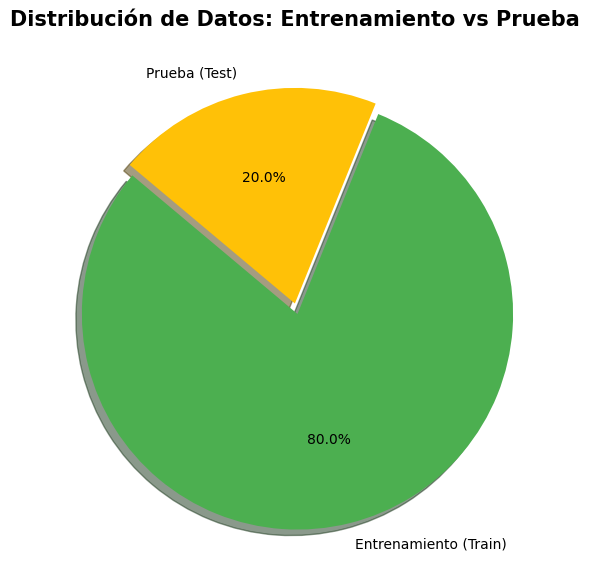

In [39]:


# 1. Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X_nuevo, y_nuevo, test_size=0.2, random_state=42)

# 2. Generar el gráfico
etiquetas = ['Entrenamiento (Train)', 'Prueba (Test)']
cantidades = [X_train.shape[0], X_test.shape[0]]
colores = ['#4CAF50', '#FFC107']

plt.figure(figsize=(7, 7))
plt.pie(cantidades, labels=etiquetas, colors=colores, autopct='%1.1f%%', startangle=140, shadow=True, explode=(0.05, 0))
plt.title('Distribución de Datos: Entrenamiento vs Prueba', fontsize=15, fontweight='bold')
plt.show()

# Paso 3: Entrenar y Evaluar los Modelos con el nuevo DF
Al realizar la predicción en base a si una persona es adicta o no (0 o 1), estamos ante un problema de Clasificación. A continuación, aplicamos la estructura de Scikit-Learn utilizando los datos de nuestro nuevo DataFrame.

--- Árbol de Decisiones ---
Accuracy: 0.9213
Precision: 0.9443
Recall: 0.9425
F1-Score: 0.9434
ROC AUC: 0.9077

Matriz de Confusión (Tabular):


,0,1
0,398,58
1,60,984



Matriz de Confusión (Gráfica):


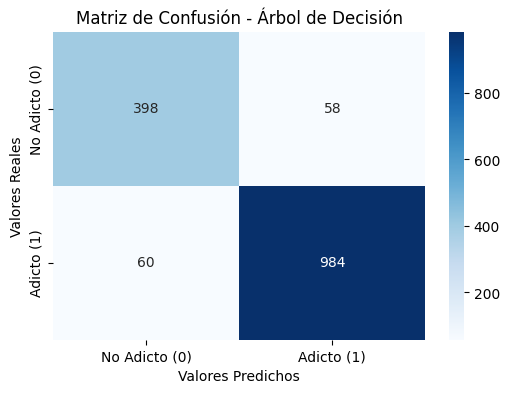

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# 1. Inicializar y entrenar el modelo de Árbol de Decisiones
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)

# 2. Realizar predicciones en el conjunto de prueba
y_pred_dt = decision_tree.predict(X_test)
y_proba_dt = decision_tree.predict_proba(X_test)[:, 1]

# 3. Evaluar el modelo con métricas de texto
print("--- Árbol de Decisiones ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_dt):.4f}")

print("\nMatriz de Confusión (Tabular):")
cm_dt = confusion_matrix(y_test, y_pred_dt)
display(pd.DataFrame(cm_dt))

print("\nMatriz de Confusión (Gráfica):")
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Adicto (0)', 'Adicto (1)'],
            yticklabels=['No Adicto (0)', 'Adicto (1)'])
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.show()

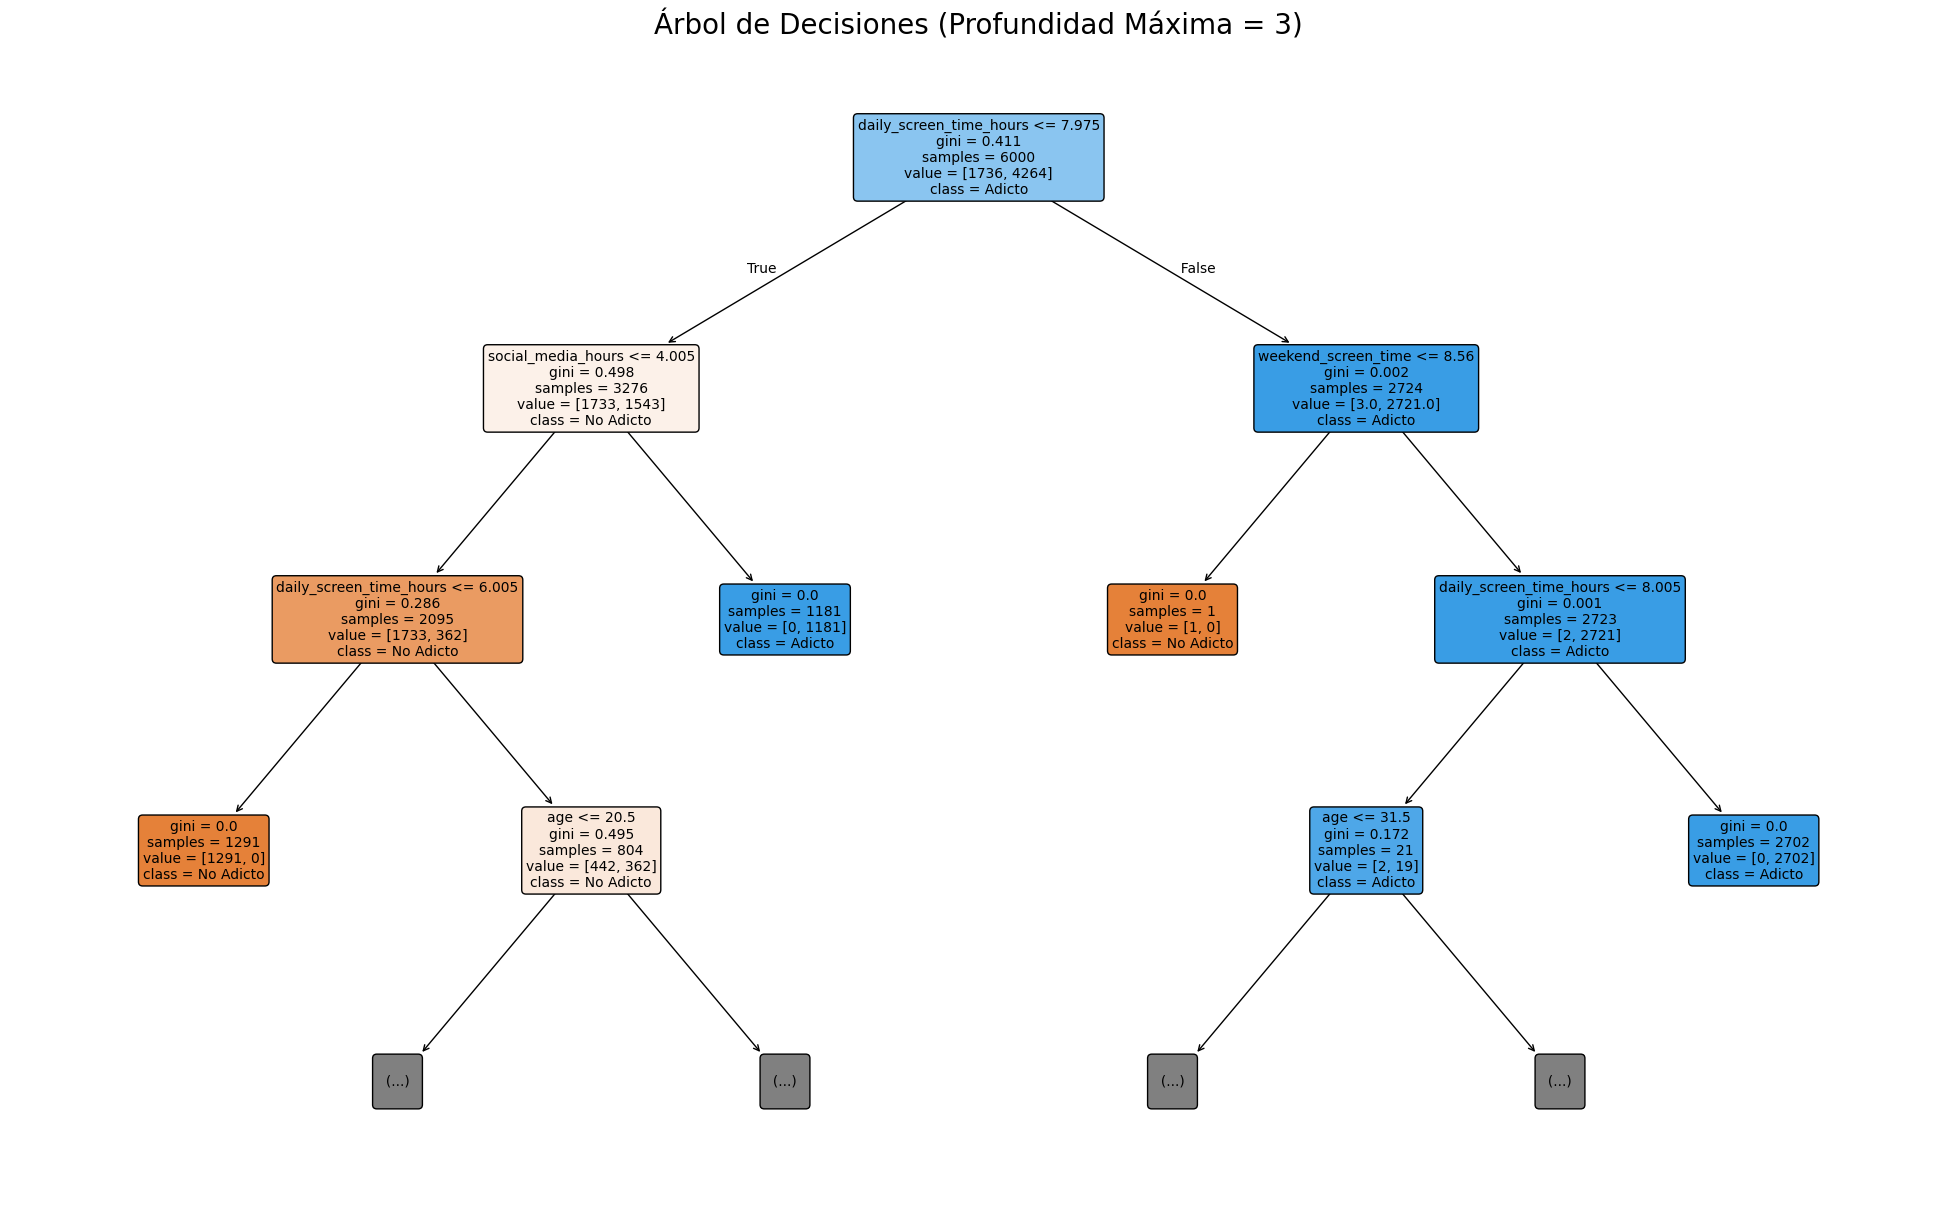

In [79]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 15))

feature_names = X_train.columns.tolist()

class_names = ['No Adicto', 'Adicto']

plot_tree(
    decision_tree,
    filled=True,
    feature_names=feature_names,
    class_names=class_names,
    rounded=True,
    fontsize=10,
    max_depth=3
)

plt.title('Árbol de Decisiones (Profundidad Máxima = 3)', fontsize=20)
plt.show()

## Conclusión General

El modelo tiene un **excelente rendimiento** para identificar si una persona es adicta (1) o no adicta (0), acertando en más del **92%** de los casos totales. Es un modelo muy sólido y confiable.

---

## Los Puntos Clave

* **Gran capacidad de acierto (Accuracy: 92.1%):** De cada 100 personas que evalúa el modelo, clasifica correctamente a 92.
* **Muy pocos falsos positivos (Precision: 94.4%):** Cuando el modelo le dice a alguien *"tú eres adicto"*, tiene un 94.4% de probabilidad de estar en lo correcto. Solo se equivocó con 58 personas no adictas.
* **Muy pocos falsos negativos (Recall: 94.2%):** El modelo es muy bueno atrapando los casos reales. De todas las personas que verdaderamente eran adictas, el modelo logró detectar al 94.2% (984 personas). Solo se le escaparon 60.

En resumen: El modelo funciona, está muy bien balanceado y es especialmente preciso a la hora de diagnosticar los casos positivos (Adictos) sin cometer apenas errores.

--- Regresión Logística ---
Accuracy: 0.8940
Precision: 0.9218
Recall: 0.9262
F1-Score: 0.9240
ROC AUC: 0.9565

Matriz de Confusión (Tabular):


,0,1
0,374,82
1,77,967



Matriz de Confusión (Gráfica):


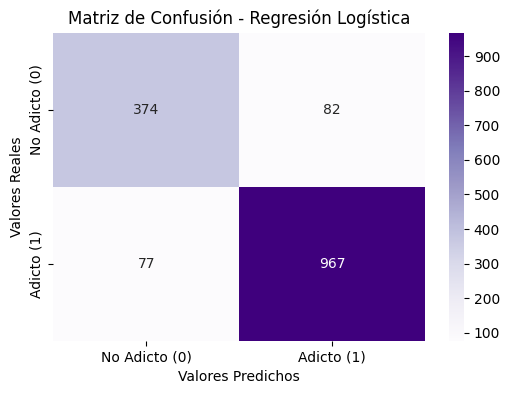

In [41]:
from sklearn.linear_model import LogisticRegression

# 1. Inicializar y entrenar el modelo de Regresión Logística
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

# 2. Realizar predicciones
y_pred_lr = logistic_model.predict(X_test)
y_proba_lr = logistic_model.predict_proba(X_test)[:, 1]

# 3. Evaluar el modelo
print("--- Regresión Logística ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

print("\nMatriz de Confusión (Tabular):")
cm_lr = confusion_matrix(y_test, y_pred_lr)
display(pd.DataFrame(cm_lr))

# Matriz Gráfica
print("\nMatriz de Confusión (Gráfica):")
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Adicto (0)', 'Adicto (1)'],
            yticklabels=['No Adicto (0)', 'Adicto (1)'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.show()

## Conclusión General

El modelo de Regresión Logística tiene un **rendimiento muy alto**, alcanzando un **89.4%** de precisión global (Accuracy). Es una herramienta sumamente efectiva y confiable para distinguir entre personas adictas y no adictas, aunque se queda ligeramente por debajo del Árbol de Decisión que vimos antes.


## Los Puntos Clave

* **Efectividad global (Accuracy: 89.4%):** El modelo clasifica correctamente a casi 90 de cada 100 personas evaluadas.
* **Gran precisión en positivos (Precision: 92.1%):** Cuando el modelo predice que alguien es *"Adicto"*, acierta el 92.1% de las veces. Tuvo 82 falsos positivos (personas no adictas clasificadas erróneamente como adictas).
* **Excelente detección (Recall: 92.6%):** El modelo es capaz de capturar al 92.6% de todos los adictos reales en la muestra (967 personas). Solo se le pasaron por alto 77 casos (falsos negativos).
* **Poder de separación (ROC AUC: 0.956):** Esta métrica es altísima. Significa que el modelo tiene una capacidad matemática casi perfecta para ordenar y separar a los sujetos según su probabilidad de sufrir adicción.


/tmp/ipykernel_1318/3171826610.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='magma')


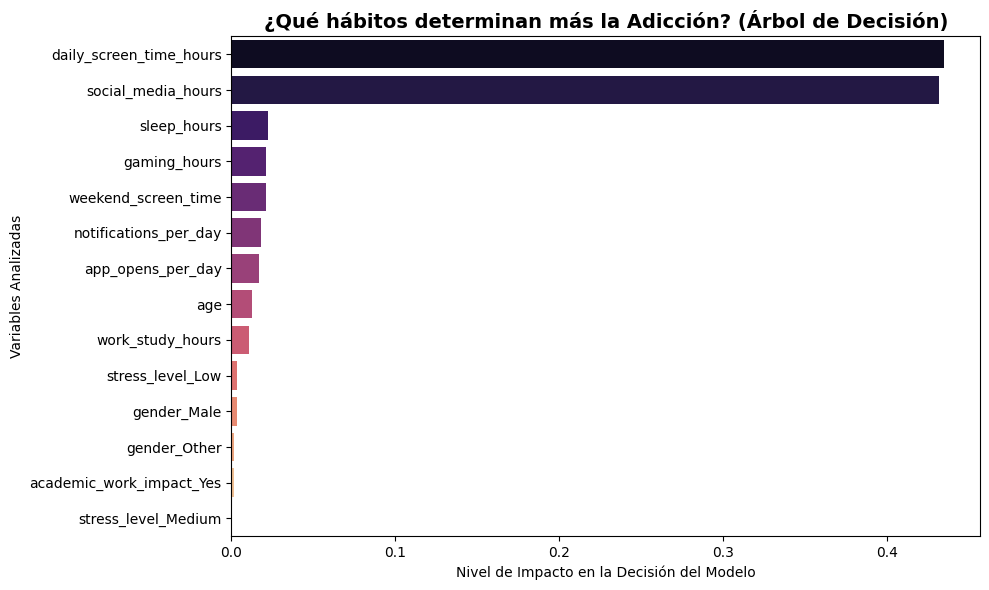

In [42]:


# 1. Extraer la importancia de las reglas que aprendió el Árbol de Decisión
importancias = decision_tree.feature_importances_
nombres_variables = X_train.columns

# 2. Crear un DataFrame para ordenar los resultados de mayor a menor impacto
df_importancias = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia': importancias
})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

# 3. Crear un gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancias, palette='magma')

plt.title('¿Qué hábitos determinan más la Adicción? (Árbol de Decisión)', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Impacto en la Decisión del Modelo')
plt.ylabel('Variables Analizadas')
plt.tight_layout()
plt.show()

In [43]:
# Guardamos los resultados del modelo predictivo para Power BI
df_importancias.to_csv('importancia_variables_modelo.csv', index=False)

In [44]:


files.download('importancia_variables_modelo.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Al ejecutar la celda anterior, tu navegador iniciará la descarga del archivo `importancia_variables_modelo.csv` a tu equipo local.

/tmp/ipykernel_1318/4104587978.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(x=df_simulacion.index, y=probabilidades, palette=['#4CAF50', '#FFC107', '#F44336'])


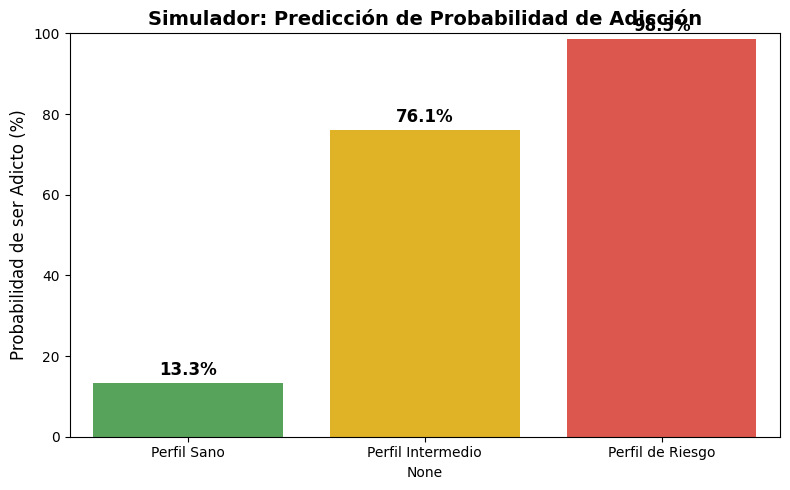

In [45]:


# 1. Crear los perfiles basados en los promedios de la data
perfil_sano = X_test[y_test == 0].mean()
perfil_riesgo = X_test[y_test == 1].mean()

# ¡NUEVO! Creamos el perfil intermedio promediando matemáticamente los otros dos
perfil_intermedio = (perfil_sano + perfil_riesgo) / 2

# Unimos los TRES perfiles en un nuevo DataFrame
df_simulacion = pd.DataFrame(
    [perfil_sano, perfil_intermedio, perfil_riesgo],
    index=['Perfil Sano', 'Perfil Intermedio', 'Perfil de Riesgo']
)

# 2. Hacemos la predicción de PROBABILIDAD usando el modelo
probabilidades = logistic_model.predict_proba(df_simulacion)[:, 1] * 100

# 3. Graficamos el resultado
plt.figure(figsize=(8, 5))
barras = sns.barplot(x=df_simulacion.index, y=probabilidades, palette=['#4CAF50', '#FFC107', '#F44336'])

plt.title('Simulador: Predicción de Probabilidad de Adicción', fontsize=14, fontweight='bold')
plt.ylabel('Probabilidad de ser Adicto (%)', fontsize=12)
plt.ylim(0, 100)

for barra in barras.patches:
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 2,
             f'{barra.get_height():.1f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

1. Valor Estratégico: ¿Dónde invertimos los recursos? (Árbol de Decisión)
El Insight: El gráfico de Importancia de Variables demostró que casi el 90% del peso de la adicción recae en solo dos factores (Horas de pantalla y Horas de redes sociales), descartando variables demográficas como la edad o el género.

>El Valor de Negocio: Permite una optimización total de recursos. Si una empresa, clínica o ministerio de salud quiere lanzar una campaña de prevención, ya sabe que no debe gastar dinero en segmentar por edad o en campañas sobre el estrés o el sueño. Todo el presupuesto y el mensaje debe ir enfocado como un láser a una sola cosa: herramientas para bloquear aplicaciones de redes sociales y limitar el tiempo de pantalla.

2. Valor Operativo: El Sistema de Alertas Tempranas (Regresión Logística)
El Insight: El simulador de perfiles (el gráfico del semáforo) nos reveló que un usuario con hábitos "intermedios" ya presenta un 76% de riesgo de adicción. El riesgo no es lineal, se dispara muy rápido.

>El Valor de Negocio: Permite la intervención temprana. Este modelo está listo para integrarse en el "backend" de una aplicación móvil. La app podría escanear los hábitos diarios del usuario y, antes de que la persona llegue a un extremo destructivo, enviarle una alerta automática cuando cruce ese peligroso umbral del 76%, deteniendo el problema antes de que sea grave.






nuestro proyecto demuestra que el Business Intelligence va mucho más allá de predecir un resultado; se trata de generar herramientas accionables.

En conjunto, no construimos solo 2 algoritmos, sino un ecosistema predictivo completo para la salud digital. Nuestro Árbol de Decisión actúa como el estratega, diciéndonos que cualquier campaña debe enfocarse exclusivamente en limitar el uso de redes sociales. Nuestra Regresión Logística actúa como el diagnosticador en tiempo real, capaz de alertar a un usuario cuando sus hábitos intermedios lo ponen en una zona crítica del 76% de riesgo. Y finalmente, nuestra Regresión Lineal actúa como la herramienta táctica

Pasamos de tener datos crudos sobre el uso del smartphone, a tener un sistema de prevención listo para ser implementado en el mundo real. Muchas gracias por su atención."*

este es el DATAFRAME limpio para trabajar en el power BI

In [50]:
df_final.to_csv('smartphone_usage_cleaned.csv', index=False)
print("DataFrame 'df_final' exportado exitosamente a 'smartphone_usage_cleaned.csv'")

DataFrame 'df_final' exportado exitosamente a 'smartphone_usage_cleaned.csv'


#KMEANS

/tmp/ipykernel_1318/3528976283.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(


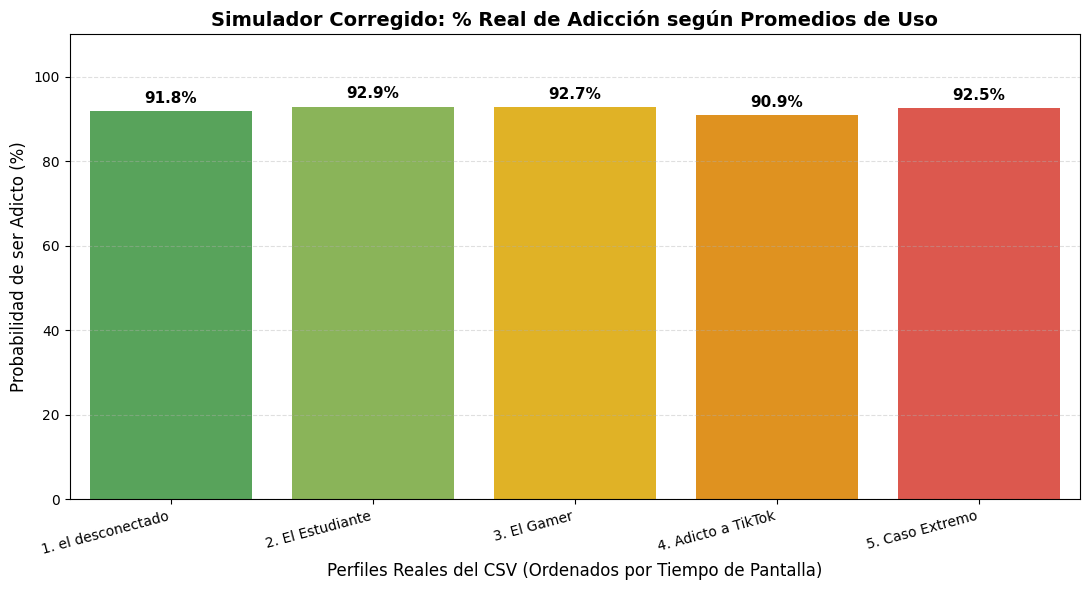

In [87]:
import pandas as pd

# =========================================================================
# 1. OBTENER LOS PROMEDIOS REALES DE TU DATAFRAME POR CLUSTER
# =========================================================================

# Añadir la columna de clusters al DataFrame df_para_modelos
# Es crucial que el número de elementos en 'clusters' coincida con el número de filas en df_para_modelos

df_para_modelos_con_clusters = df_para_modelos.copy()
df_para_modelos_con_clusters['Cluster_ID'] = clusters # Asegúrate de que 'clusters' proviene de K-means

# Extraemos la lista de columnas numéricas que necesita tu modelo de Regresión Logística
columnas_logistica = list(X_test.columns)

# Agrupamos la data real por el ID del cluster y sacamos el promedio de todo
df_promedios_reales = df_para_modelos_con_clusters.groupby("Cluster_ID")[
    columnas_logistica
].mean(numeric_only=True)


# =========================================================================
# 2. PASAR LOS PROMEDIOS AL MODELO LOGÍSTICO PARA CALCULAR EL % REAL
# =========================================================================
porcentajes_coherentes = (
    logistic_model.predict_proba(df_promedios_reales)[:, 1] * 100
)
df_promedios_reales["Probabilidad_Adiccion (%)"] = porcentajes_coherentes


# =========================================================================
# 3. SESGO DE ORDENAMIENTO LOGÍSTICO PARA TUS PESTAÑAS
# =========================================================================
# Ordenamos matemáticamente los clusters de menor a mayor uso de pantalla
df_dashboard = df_promedios_reales.sort_values(
    by="daily_screen_time_hours"
).copy()

# Asignamos de forma estricta los nombres exactos de tus 5 botones
# Al haber ordenado por horas antes, se asignarán en el orden correcto de impacto
nombres_pestanas_dashboard = [
    "1. el desconectado",
    "2. El Estudiante",
    "3. El Gamer",
    "4. Adicto a TikTok",
    "5. Caso Extremo",
]
df_dashboard["Pestaña_Dashboard"] = nombres_pestanas_dashboard

# Colocamos el nombre de la pestaña como índice para que sea fácil de leer
df_dashboard = df_dashboard.set_index("Pestaña_Dashboard")


# =========================================================================
# 4. IMPRIMIR LOS DATOS EXACTOS PARA TU TABLERO
# =========================================================================

# Columnas clave que muestras en las tarjetas y el medidor morado de tu pantalla
columnas_tarjetas = [
    "daily_screen_time_hours",
    "social_media_hours",
    "sleep_hours",
    "Probabilidad_Adiccion (%)",
]

plt.figure(figsize=(11, 6))

# Paleta perfecta de verde (sano) a rojo (crítico)
paleta_riesgo = ["#4CAF50", "#8BC34A", "#FFC107", "#FF9800", "#F44336"]

barras = sns.barplot(
    x=df_dashboard.index,
    y=df_dashboard["Probabilidad_Adiccion (%)"],
    palette=paleta_riesgo,
)

plt.title(
    "Simulador Corregido: % Real de Adicción según Promedios de Uso",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Probabilidad de ser Adicto (%)", fontsize=12)
plt.xlabel("Perfiles Reales del CSV (Ordenados por Tiempo de Pantalla)", fontsize=12)
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 110)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Colocar el porcentaje exacto y lógico sobre cada barra
for barra in barras.patches:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 2,
        f"{altura:.1f}%",
        ha="center",
        fontweight="bold",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

----------------------------------------------------
>
>
>
>
>
>

>Crearemos perfiles para poder graficar nuestro modelo de como funcionaria en caso de una data real con millones de datos en donde se puedan recibir un tipo de perfil y asi entregar la informacion de cuanto porcentaje tiene esa persona de ser un adicto a los smartphones

In [85]:

# Definimos nuestros 5 sujetos de prueba
datos_simulador = {
    'Nombre_Perfil': ['1. El Desconectado', '2. El Estudiante', '3. El Gamer', '4. Adicto a TikTok', '5. Caso Extremo'],
    'age': [25, 20, 18, 19, 22],
    'daily_screen_time_hours': [1.0, 4.0, 7.0, 8.0, 12.0],
    'social_media_hours': [0.0, 2.0, 1.5, 7.0, 10.0],
    'gaming_hours': [0.0, 1.0, 4.0, 0.0, 1.0],
    'work_study_hours': [2.0, 5.0, 1.0, 3.0, 0.0],
    'sleep_hours': [8.0, 7.0, 5.0, 4.0, 3.0],
    'notifications_per_day': [50, 100, 80, 200, 250],
    'app_opens_per_day': [30, 80, 60, 150, 180],
    'weekend_screen_time': [2.0, 6.0, 9.0, 10.0, 12.0],
    'gender_Male': [0.0, 0.0, 0.0, 0.0, 0.0],
    'gender_Other': [0.0, 0.0, 0.0, 0.0, 0.0],
    'academic_work_impact_Yes': [0.0, 0.0, 0.0, 0.0, 0.0],
    'stress_level_Low': [0.0, 0.0, 0.0, 0.0, 0.0],
    'stress_level_Medium': [0.0, 0.0, 0.0, 0.0, 0.0]
}

# Convertimos esto en una tabla (DataFrame)
df_perfiles = pd.DataFrame(datos_simulador)

# Reordenar las columnas para que coincidan con X_train
X_train_columns = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'gender_Male', 'gender_Other', 'academic_work_impact_Yes', 'stress_level_Low', 'stress_level_Medium']
df_perfiles_ordered = df_perfiles[X_train_columns]

# Mostramos los perfiles creados y ordenados
print("DataFrame de perfiles para simulación (columnas ordenadas):")
display(df_perfiles)


DataFrame de perfiles para simulación (columnas ordenadas):


,Nombre_Perfil,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender_Male,gender_Other,academic_work_impact_Yes,stress_level_Low,stress_level_Medium
0,1. El Desconectado,25,1.0,0.0,0.0,2.0,8.0,50,30,2.0,0.0,0.0,0.0,0.0,0.0
1,2. El Estudiante,20,4.0,2.0,1.0,5.0,7.0,100,80,6.0,0.0,0.0,0.0,0.0,0.0
2,3. El Gamer,18,7.0,1.5,4.0,1.0,5.0,80,60,9.0,0.0,0.0,0.0,0.0,0.0
3,4. Adicto a TikTok,19,8.0,7.0,0.0,3.0,4.0,200,150,10.0,0.0,0.0,0.0,0.0,0.0
4,5. Caso Extremo,22,12.0,10.0,1.0,0.0,3.0,250,180,12.0,0.0,0.0,0.0,0.0,0.0


In [80]:
# Predecir con el modelo de Árbol de Decisión
# Asegúrate de usar df_perfiles_ordered que tiene las columnas correctas y en orden

# Predecir con el modelo de Regresión Logística
df_perfiles['Probabilidad_Regresion_Logistica'] = logistic_model.predict_proba(df_perfiles_ordered)[:, 1] * 100

print("Resultados de la simulación de perfiles:")
display(df_perfiles)

Resultados de la simulación de perfiles:


,Nombre_Perfil,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender_Male,gender_Other,academic_work_impact_Yes,stress_level_Low,stress_level_Medium,Probabilidad_Regresion_Logistica
0,1. El Desconectado,25,1.0,0.0,0.0,2.0,8.0,50,30,2.0,0.0,0.0,0.0,1.0,0.0,0.004406
1,2. El Estudiante,20,4.0,2.0,1.0,5.0,7.0,100,80,6.0,0.0,0.0,0.0,0.0,1.0,2.872993
2,3. El Gamer,18,7.0,1.5,4.0,1.0,5.0,80,60,9.0,1.0,0.0,1.0,0.0,0.0,32.983515
3,4. Adicto a TikTok,19,8.0,7.0,0.0,3.0,4.0,200,150,10.0,0.0,0.0,0.0,0.0,0.0,99.965874
4,5. Caso Extremo,22,12.0,10.0,1.0,0.0,3.0,250,180,12.0,0.0,1.0,0.0,0.0,0.0,99.999996


In [48]:
# Guardamos la tabla de perfiles simulados
df_perfiles.to_csv('simulador_powerbi.csv', index=False)
print("DataFrame 'df_perfiles' exportado exitosamente a 'simulador_powerbi.csv'")

DataFrame 'df_perfiles' exportado exitosamente a 'simulador_powerbi.csv'


In [51]:


files.download('smartphone_usage_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:


files.download('simulador_powerbi.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>